In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0,'./g3code/')
from g3group import g3groupfinder as g3gf
from survey_volume import comoving_volume

In [4]:
df = pd.read_parquet('waves_gals_groupfinding.parquet')

# Setup footprints and calculate volume

In [5]:
len(df)/1e6

2.329254

In [6]:
in_footprint1 = (df.ra < 60)
in_footprint2 = (df.ra > 60) & (df.ra < 300)
in_footprint3 = (df.ra > 300)
footprint = 1*in_footprint1 + 2*in_footprint2 + 3*in_footprint3
df.loc[:,'footprint'] = footprint

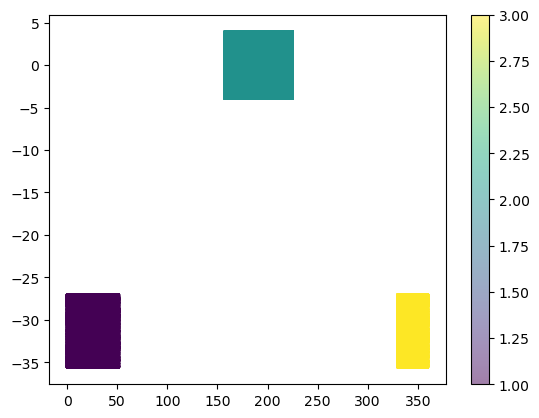

In [7]:
plt.figure()
sc=plt.scatter(df['ra'],df['dec'], c=footprint, alpha=0.5, s=1, rasterized=True)
plt.colorbar(sc)
plt.show()

In [8]:
fp1 = df[df.footprint==1]
fp2 = df[df.footprint==2]
fp3 = df[df.footprint==3]

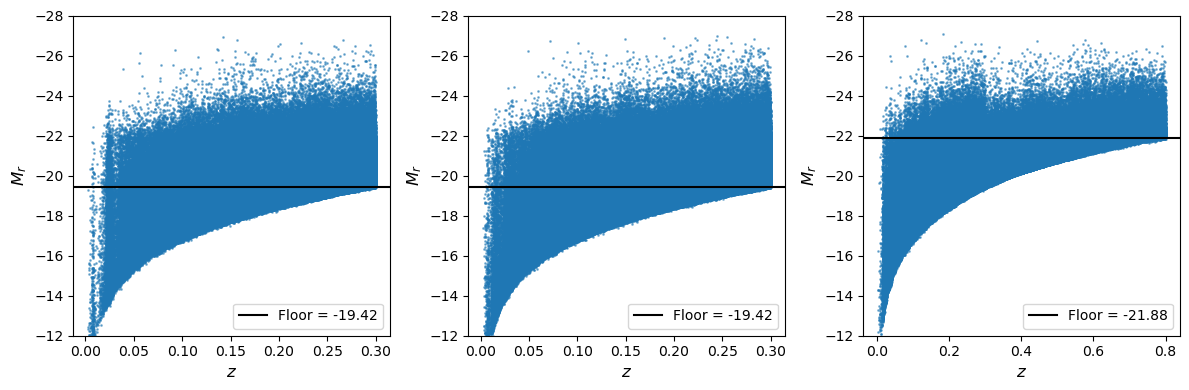

In [9]:
fig, axs = plt.subplots(ncols=3, figsize=(12,4))
axs[0].scatter(fp1.zobs, fp1.total_ab_dust_r_SDSS, s=1, rasterized=True, alpha=0.5)
axs[1].scatter(fp2.zobs, fp2.total_ab_dust_r_SDSS, s=1, rasterized=True, alpha=0.5)
axs[2].scatter(fp3.zobs, fp3.total_ab_dust_r_SDSS, s=1, rasterized=True, alpha=0.5)

fp1_floor = np.percentile(fp1[fp1.zobs > 0.95*np.max(fp1.zobs)].total_ab_dust_r_SDSS, 98)
fp2_floor = np.percentile(fp2[fp2.zobs > 0.95*np.max(fp2.zobs)].total_ab_dust_r_SDSS, 98)
fp3_floor = np.percentile(fp3[fp3.zobs > 0.95*np.max(fp3.zobs)].total_ab_dust_r_SDSS, 98)
axs[0].axhline(fp1_floor, color='k', label=f'Floor = {fp1_floor:0.2f}')
axs[1].axhline(fp2_floor, color='k', label=f'Floor = {fp2_floor:0.2f}')
axs[2].axhline(fp3_floor, color='k', label=f'Floor = {fp3_floor:0.2f}')

for ax_ in axs:
    ax_.set_ylim(-12,-28)
    ax_.set_xlabel('$z$',fontsize=12)
    ax_.set_ylabel('$M_r$',fontsize=12)
    ax_.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [10]:
fp1vol = comoving_volume(fp1.ra.min(), fp1.ra.max(), fp1.dec.min(), fp1.dec.max(), fp1.zobs.min(), fp1.zobs.max(), 70, 0.3, 0.7)
fp2vol = comoving_volume(fp2.ra.min(), fp2.ra.max(), fp2.dec.min(), fp2.dec.max(), fp2.zobs.min(), fp2.zobs.max(), 70, 0.3, 0.7)
fp3vol = comoving_volume(fp3.ra.min(), fp3.ra.max(), fp3.dec.min(), fp3.dec.max(), fp3.zobs.min(), fp3.zobs.max(), 70, 0.3, 0.7)

In [11]:
fp1vol/1e6, fp2vol/1e6, fp3vol/1e6

(np.float64(65.539994123037),
 np.float64(92.5271890381717),
 np.float64(484.4571619334844))

# Group Finding Test Run

In [ ]:
# output = g3gf(fp1.ra,fp1.dec,3e5*fp1.zobs,fp1.total_ab_dust_r_SDSS,fp1_floor,\
#                  fof_bperp=0.07,fof_blos=1.1, volume=fp1vol, center_mode='average',\
#                  iterative_giant_only_groups=True, n_bootstraps=5000, rproj_fit_guess=None, rproj_fit_params = None, rproj_fit_multiplier=None,\
#                  vproj_fit_guess = None, vproj_fit_params = None, vproj_fit_multiplier=None, vproj_fit_offset=0, gd_rproj_fit_guess=None, gd_rproj_fit_params = None,\
#                  gd_rproj_fit_multiplier=None, gd_vproj_fit_guess=None, gd_vproj_fit_params = None, gd_vproj_fit_multiplier=None,gd_vproj_fit_offset=None,
#                  gd_fit_bins=None,ic_center_mode='arithmetic', ic_decision_mode='centers',H0=100., Om0=0.3, Ode0=0.7, showplots=False, saveplotspdf=False)

FoF completed in 0.618 s.


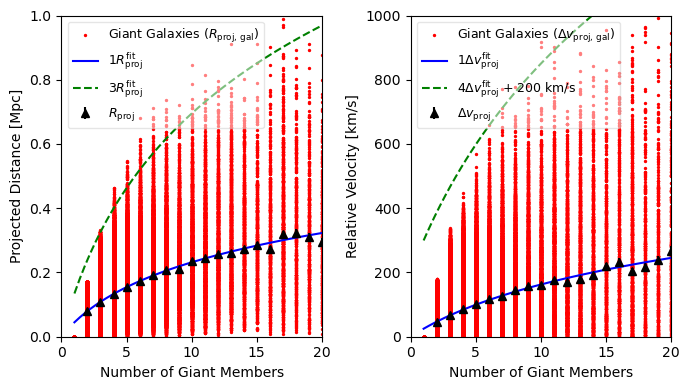

Giant-only iterative combination 1 in progress...
Giant-only iterative combination 2 in progress...
Giant-only iterative combination 3 in progress...
Giant-only iterative combination 4 in progress...
Giant-only iterative combination 5 in progress...
Giant-only iterative combination complete.
Associating dwarfs to giant-only groups...


100%|████████████████████████████████| 323698/323698 [00:09<00:00, 35134.73it/s]


Dwarf association complete.


/Users/zhutchens/Documents/research/fourhs/g3code/g3misc.py:169: RuntimeWarning: overflow encountered in power
  Mi_terms = np.power(10, -0.4*galmag)


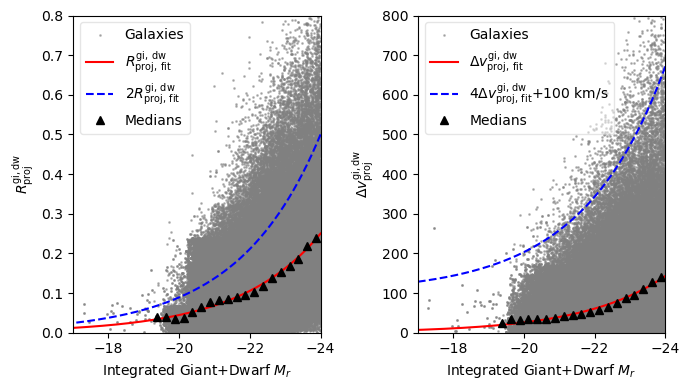

Dwarf-only iterative combination 1 in progress...
Dwarf-only iterative combination 2 in progress...
Dwarf-only iterative combination 3 in progress...
Dwarf-only iterative combination 4 in progress...
Dwarf-only iterative combination complete.


/Users/zhutchens/Documents/research/fourhs/g3code/g3misc.py:169: RuntimeWarning: overflow encountered in power
  Mi_terms = np.power(10, -0.4*galmag)


In [14]:
fp1_g3obj = g3gf(fp1.ra, fp1.dec, fp1.zobs, fp1.total_ab_dust_r_SDSS,fp1_floor, precision=np.float64)
fofid = fp1_g3obj.giantOnlyFOF(0.07, 1.1, 4.84)
fp1_g3obj.deriveGiantCalibrations(rproj_fit_multiplier=3, vproj_fit_multiplier=4, vproj_fit_offset=200)
fp1_g3obj.plotGiantGroupBoundaries(show=True)
fp1_g3obj.giantOnlyMerging()
fp1_g3obj.dwarfAssoc()
fp1_g3obj.deriveDwarfBoundaries(gd_rproj_fit_multiplier=2, gd_vproj_fit_multiplier=4, gd_vproj_fit_offs=100, gd_fit_bins=np.arange(-24,-19,0.25))
fp1_g3obj.plotDwarfBoundaries(show=True, rproj_xlim=(-17,-24), rproj_ylim=(0,0.8), vproj_xlim=(-17,-24), vproj_ylim=(0,800))
fp1_g3obj.findDwarfOnlyGroups()
cat = fp1_g3obj.getCatalog(by='galaxy')

In [17]:
fp1

,id_galaxy_sky,ra,dec,zobs,zcos,inclination,pa,mstars_disk,mstars_bulge,log_mstar_total,...,total_ab_dust_BandX_VLA,total_ab_dust_BandC_VLA,total_ab_dust_BandS_VLA,total_ab_dust_BandL_VLA,total_ab_dust_Band_610MHz,total_ab_dust_Band_325MHz,total_ab_dust_Band_150MHz,id_fof,masked,footprint
4,51235255,28.278151,-32.583664,0.253510,0.253632,40.619167,189.561813,1.029835e+10,9.392675e+08,10.221306,...,-19.135923,-19.512106,-20.013784,-20.548386,-21.216757,-21.755157,-22.457918,-1,False,1
8,17183512,28.609648,-28.424871,0.024037,0.025891,78.209877,160.035156,1.018892e+08,0.000000e+00,8.178761,...,-10.724882,-11.101064,-11.602743,-12.137343,-12.805716,-13.344115,-14.046878,1198360,False,1
12,13463803,21.815357,-28.049517,0.247103,0.246712,71.474930,93.804161,2.076097e+09,3.090405e+08,9.548145,...,-16.418066,-16.794249,-17.295927,-17.830528,-18.498899,-19.037300,-19.740063,-1,False,1
16,86895230,15.994211,-35.455189,0.233827,0.232173,47.221104,40.226955,1.257317e+07,6.814840e+10,11.004168,...,-14.397353,-14.773535,-15.275214,-15.809814,-16.478188,-17.016586,-17.719349,18141786,False,1
17,96543412,15.315541,-31.570852,0.143772,0.143122,30.592813,1.777300,1.174966e+10,5.874351e+10,11.018779,...,-17.111666,-17.487846,-17.989525,-18.524126,-19.192497,-19.730898,-20.433661,20176766,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329229,90956606,9.398425,-34.521461,0.209063,0.207855,89.686134,301.519135,7.331827e+09,2.465348e+09,10.161733,...,-18.495245,-18.871428,-19.373106,-19.907707,-20.576078,-21.114479,-21.817242,18977796,False,1
2329234,9578297,26.344536,-33.980579,0.166883,0.167792,25.773802,235.386902,5.848183e+09,4.501822e+08,9.969860,...,-17.995972,-18.372152,-18.873831,-19.408432,-20.076805,-20.615204,-21.317966,2007548,False,1
2329239,108145532,17.864330,-27.836435,0.115168,0.113013,39.804321,304.246338,1.196368e+09,1.089323e+08,9.286343,...,-15.465644,-15.841825,-16.343504,-16.878105,-17.546478,-18.084877,-18.787640,-1,False,1
2329242,102189436,22.809752,-29.879379,0.167688,0.166932,66.326233,109.388565,2.854343e+09,5.571491e+07,9.634534,...,-17.479780,-17.855963,-18.357641,-18.892242,-19.560614,-20.099014,-20.801777,-1,False,1


In [ ]:
plt.figu